In [ ]:
!pip install torchinfo
!pip install torchmetrics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.2/983.2 kB 20.5 MB/s eta 0:00:00


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os
# ------------------------ for the splitting of dataset ------------------------
import random
from pathlib import Path
# ------------------------for the lebling of dataset ------------------------
from torchvision import datasets, transforms
from torch.utils.data import DataLoader #turn the dataset into iterable and also for batching
from PIL import Image
from typing import List
# ------------------------ ------------------------
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import models  # ------------------
from sklearn.metrics import precision_score, recall_score, f1_score
# ------------------------ for plotting the curves ------------------------
import matplotlib.pyplot as plt
# ------------------------ for getting the summary of the model ------------------------
from torchinfo import summary

import json # To save metrics

KeyboardInterrupt: 

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

In [ ]:
import torch

if torch.cuda.is_available():
    print("CUDA is available.")
    print(f"Device name: {torch.cuda.get_device_name(0)}")
    print(f"Device capability: {torch.cuda.get_device_capability(0)}")
    print(f"Total memory: {torch.cuda.get_device_properties(0).total_memory / 1024**3:.2f} GB")
else:
    print("CUDA is not available. Using CPU.")
    !lscpu

# Section #1


In [ ]:

def walk_through_dir(dir_path):
    for dirpath, dirname, filenames in os.walk(dir_path):
        print(f"There are {len(dirname)} directories and {len(filenames)} images in '{dirpath}'")


dataset_path = "/content/drive/MyDrive/colon_after_splitting"
walk_through_dir(dataset_path)

In [ ]:
train_dir = os.path.join(dataset_path, "train")
val_dir   = os.path.join(dataset_path, "val")

In [ ]:
train_transform = transforms.Compose([

    transforms.Resize (size = (224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),

])

val_transform = transforms.Compose([
  transforms.Resize (size = (224, 224)),
   transforms.ToTensor(),
      transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),

 ])


In [ ]:
train_dataset = datasets.ImageFolder(train_dir, transform = train_transform)
val_dataset   = datasets.ImageFolder(val_dir, transform = val_transform)

print("Original class mapping:", train_dataset.class_to_idx)
print("---------------------------------------------------------")
print (train_dataset)
print("=====================================================")
print (val_dataset)

Original class mapping: {'colon_aca': 0, 'colon_n': 1}
---------------------------------------------------------
Dataset ImageFolder
    Number of datapoints: 8000
    Root location: /content/drive/MyDrive/colon_after_splitting/train
    StandardTransform
Transform: Compose(
               Resize(size=(224, 224), interpolation=bilinear, max_size=None, antialias=True)
               ToTensor()
               Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
           )
Dataset ImageFolder
    Number of datapoints: 1000
    Root location: /content/drive/MyDrive/colon_after_splitting/val
    StandardTransform
Transform: Compose(
               Resize(size=(224, 224), interpolation=bilinear, max_size=None, antialias=True)
               ToTensor()
               Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
           )


In [ ]:
print("traine dataset classes     :", train_dataset.class_to_idx, "| number of samples:", len(train_dataset))
print("validation dataset classes :", val_dataset.class_to_idx, "| number of samples:", len(val_dataset))

traine dataset classes     : {'colon_aca': 0, 'colon_n': 1} | number of samples: 8000
validation dataset classes : {'colon_aca': 0, 'colon_n': 1} | number of samples: 1000


# Section #2

- the following cells is for training


In [ ]:
batch_size = 32
n_workers = 0

train_loader = DataLoader(train_dataset,batch_size=batch_size, shuffle=True, num_workers = n_workers)
val_loader   = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

print(f"Number of training samples: {len(train_dataset)}")
print(f"Number of validation samples: {len(val_dataset)}")

print("============================================")

print(f"length of train_loader : {len(train_loader)} batches of  {batch_size}")
print(f"length of val_loader   : {len(val_loader)} batches of  {batch_size}")


Number of training samples: 8000
Number of validation samples: 1000
length of train_loader : 250 batches of  32
length of val_loader   : 32 batches of  32


In [ ]:
num_classes = 1 # binary classification

model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)


for param in model.parameters():
    param.requires_grad = False

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

model.fc = nn.Sequential(
nn.Flatten(),
nn.Dropout(0.5),
nn.Linear(512, 256),
nn.ReLU(),
nn.Dropout(0.5),
nn.Linear(256, num_classes))

model = model.to(device)


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 208MB/s]


In [ ]:
from torchinfo import summary

summary(model, input_size=(1, 3, 224, 224))

Layer (type:depth-idx)                   Output Shape              Param #
ResNet                                   [1, 1]                    --
├─Conv2d: 1-1                            [1, 64, 112, 112]         (9,408)
├─BatchNorm2d: 1-2                       [1, 64, 112, 112]         (128)
├─ReLU: 1-3                              [1, 64, 112, 112]         --
├─MaxPool2d: 1-4                         [1, 64, 56, 56]           --
├─Sequential: 1-5                        [1, 64, 56, 56]           --
│    └─BasicBlock: 2-1                   [1, 64, 56, 56]           --
│    │    └─Conv2d: 3-1                  [1, 64, 56, 56]           (36,864)
│    │    └─BatchNorm2d: 3-2             [1, 64, 56, 56]           (128)
│    │    └─ReLU: 3-3                    [1, 64, 56, 56]           --
│    │    └─Conv2d: 3-4                  [1, 64, 56, 56]           (36,864)
│    │    └─BatchNorm2d: 3-5             [1, 64, 56, 56]           (128)
│    │    └─ReLU: 3-6                    [1, 64, 56, 56]   

In [ ]:
model

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [ ]:
criterion = nn.BCEWithLogitsLoss()  # Binary Cross Entropy Loss
optimizer = optim.Adam(model.parameters(), lr=1e-3)

In [ ]:
from timeit import default_timer as timer
def print_train_time (start : float,
                      end : float,
                      device : torch.device = None):

    """ print diffrence between start and end time. """

    total_time = end - start
    print(f"Total training time on {device}: {total_time:.3f} seconds")
    return total_time


#* calculating time it takes to train the model

In [ ]:
dummy_input = torch.randn(4, 3, 224, 224).to(device)
print(model(dummy_input).shape)  # Should be: torch.Size([4, 1]) to indecate binary classification

torch.Size([4, 1])


In [ ]:
from tqdm.auto import tqdm  # for progress bar

torch.manual_seed(42)
start_time = timer() # start timing

num_epochs = 20

#?---------------------------- save metrics ----------------------------
train_losses, val_losses = [], []
train_accuracies, val_accuracies = [], []
train_precisions, train_recalls, train_f1s = [], [], []
val_precisions, val_recalls, val_f1s = [], [], []
#%---------------------------- Training Loop ----------------------------
for epoch in range(num_epochs):
    model.train()

    running_loss, correct, total = 0.0, 0, 0

    all_labels, all_preds = [], []


    for inputs, labels in tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs} [Train]"):
        inputs, labels = inputs.to(device), labels.to(device)

#----------------------- train step -----------------------
        outputs = model(inputs) # &----------------------- forward pass

        labels = labels.float().unsqueeze(1)
        loss = criterion(outputs, labels) #& ------------- compute the loss (predicytions vs true labels

        optimizer.zero_grad() #& --------------------------clear the gradients, set it to zero so it start fresh for this batch/ loop
        loss.backward() #& ------------------------------- backward pass
        optimizer.step() #& ------------------------------update the weights

    #= collect loss & metrics

        probs = torch.sigmoid(outputs) #convert logits to probabilities
        predicted = (probs > 0.5).long()   #convert probabilities to binary

        running_loss += loss.item() * inputs.size(0)
        correct += (predicted == labels.long()).sum().item()
        total += labels.size(0)

#?----------------------- collect the predictions and true labels

        all_labels.extend(labels.cpu().numpy())
        all_preds.extend(predicted.cpu().numpy()) #collect true lebles and prediction across all batches

#*----------------------- compute metrics for training (storing them in the lists) -----------------------
    train_loss = running_loss / len(train_dataset)
    train_acc = correct / total
    train_precision = precision_score(all_labels, all_preds, average='binary', pos_label=0)
    train_recall = recall_score(all_labels, all_preds, average='binary', pos_label=0)
    train_f1 = f1_score(all_labels, all_preds, average='binary', pos_label=0)

    train_losses.append(train_loss)
    train_accuracies.append(train_acc)
    train_precisions.append(train_precision)
    train_recalls.append(train_recall)
    train_f1s.append(train_f1)

    #$ --------------------------------------------- Validation Loop ---------------------------------------------
    model.eval() #$---------------------------- note : the model.eval disable dropout and batchnorm layers
    val_running_loss, val_correct, val_total = 0.0,0 ,0
    val_labels_all, val_preds_all = [], []

    with torch.no_grad():

        for inputs, labels in tqdm(val_loader, desc=f"Epoch {epoch+1}/{num_epochs} [Val]"):
            inputs, labels = inputs.to(device), labels.to(device)


            #only calculate the forward pass and the loss for the validation set

            outputs = model(inputs)

            labels = labels.float().unsqueeze(1)
            loss = criterion(outputs, labels)

            probs = torch.sigmoid(outputs)
            predicted = (probs > 0.5).long()

            val_running_loss += loss.item() * inputs.size(0)
            val_correct += (predicted == labels.long()).sum().item()
            val_total += labels.size(0)

            val_labels_all.extend(labels.cpu().numpy())
            val_preds_all.extend(predicted.cpu().numpy())

    val_loss = val_running_loss / len(val_dataset)
    val_acc = val_correct / val_total
    val_precision = precision_score(val_labels_all, val_preds_all, average='binary', pos_label=0)
    val_recall = recall_score(val_labels_all, val_preds_all, average='binary', pos_label=0)
    val_f1 = f1_score(val_labels_all, val_preds_all, average='binary', pos_label=0)

    val_losses.append(val_loss)
    val_accuracies.append(val_acc)
    val_precisions.append(val_precision)
    val_recalls.append(val_recall)
    val_f1s.append(val_f1)

       # Save metrics after each epoch
    metrics = {
        "train_losses": train_losses,
        "val_losses": val_losses,
        "train_accuracies": train_accuracies,
        "val_accuracies": val_accuracies,
        "train_precisions": train_precisions,
        "train_recalls": train_recalls,
        "train_f1s": train_f1s,
        "val_precisions": val_precisions,
        "val_recalls": val_recalls,
        "val_f1s": val_f1s,
    }
    with open("training_metrics_ResNet-18.json", "w") as f:
        json.dump(metrics, f)



#*---------------------------- Print epoch metrics ----------------------------
    print(f"Epoch {epoch+1}/{num_epochs}")
    print(f"Train Loss: {train_loss:.5f}, Acc: {train_acc*100:.2f}%, Precision: {train_precision:.4f}, Recall: {train_recall:.4f}, F1: {train_f1:.4f}")
    print(f"Val   Loss: {val_loss:.5f}, Acc: {val_acc*100:.2f}%, Precision: {val_precision:.4f}, Recall: {val_recall:.4f}, F1: {val_f1:.4f}")
    print("-----------------------------------------------------------")

end_time = timer() # end timing
training_time = print_train_time(start_time,end_time, device)

Epoch 1/20 [Train]:   0%|          | 0/250 [00:00<?, ?it/s]

Epoch 1/20 [Val]:   0%|          | 0/32 [00:00<?, ?it/s]

Epoch 1/20
Train Loss: 0.18020, Acc: 92.76%, Precision: 0.9271, Recall: 0.9283, F1: 0.9277
Val   Loss: 0.03996, Acc: 98.80%, Precision: 1.0000, Recall: 0.9760, F1: 0.9879
-----------------------------------------------------------


Epoch 2/20 [Train]:   0%|          | 0/250 [00:00<?, ?it/s]

Epoch 2/20 [Val]:   0%|          | 0/32 [00:00<?, ?it/s]

...

Epoch 19/20 [Val]:   0%|          | 0/32 [00:00<?, ?it/s]

Epoch 19/20
Train Loss: 0.07402, Acc: 97.15%, Precision: 0.9696, Recall: 0.9735, F1: 0.9716
Val   Loss: 0.00740, Acc: 100.00%, Precision: 1.0000, Recall: 1.0000, F1: 1.0000
-----------------------------------------------------------


Epoch 20/20 [Train]:   0%|          | 0/250 [00:00<?, ?it/s]

Epoch 20/20 [Val]:   0%|          | 0/32 [00:00<?, ?it/s]

Epoch 20/20
Train Loss: 0.06882, Acc: 97.65%, Precision: 0.9758, Recall: 0.9772, F1: 0.9765
Val   Loss: 0.00789, Acc: 99.90%, Precision: 1.0000, Recall: 0.9980, F1: 0.9990
-----------------------------------------------------------
Total training time on cuda: 6293.588 seconds


In [ ]:
with open("training_metrics_ResNet-18.json", "r") as f:
    metrics = json.load(f)

train_losses = metrics["train_losses"]
val_losses = metrics["val_losses"]


In [ ]:
class_names = train_dataset.classes
print(f"Class names: {class_names}")

Class names: ['colon_aca', 'colon_n']


In [ ]:
import torch
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import numpy as np


In [ ]:
class_names = train_dataset.classes
print(f"Class names: {class_names}")

Class names: ['colon_aca', 'colon_n']


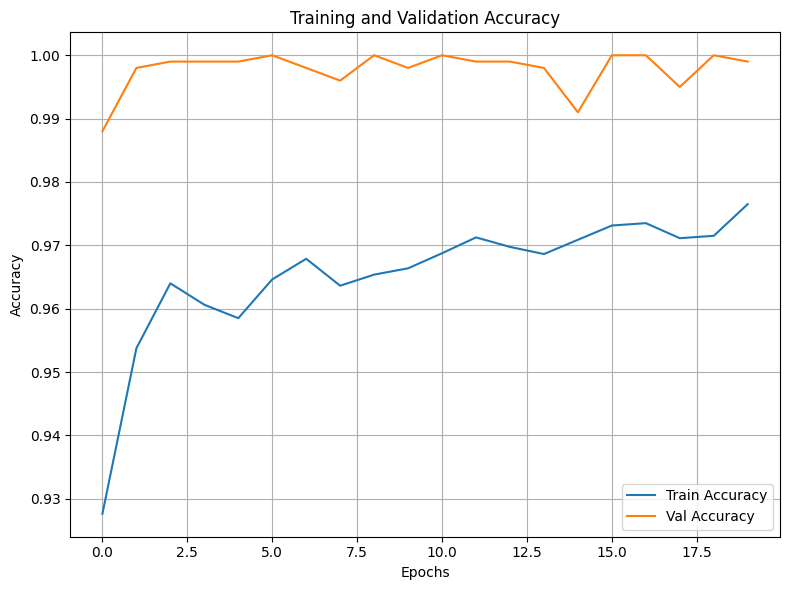

In [ ]:
plt.figure(figsize=(8,6))
plt.plot(train_accuracies, label="Train Accuracy")
plt.plot(val_accuracies, label="Val Accuracy")
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Training and Validation Accuracy')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

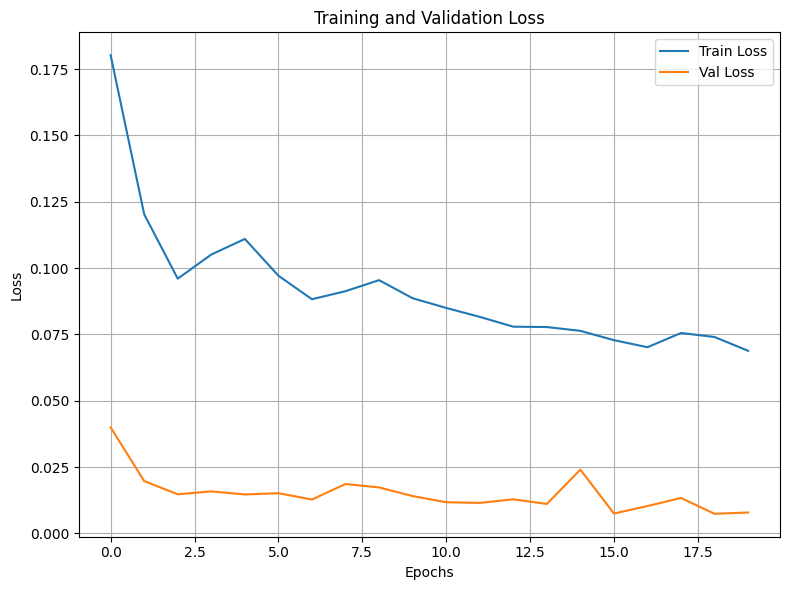

In [ ]:
plt.figure(figsize=(8,6))
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Val Loss")
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

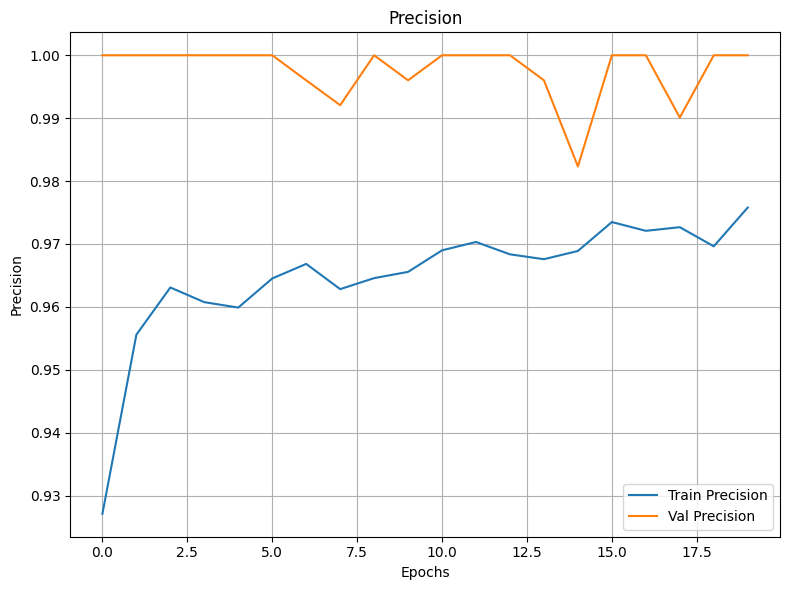

In [ ]:
plt.figure(figsize=(8,6))
plt.plot(train_precisions, label="Train Precision")
plt.plot(val_precisions, label="Val Precision")
plt.xlabel('Epochs')
plt.ylabel('Precision')
plt.title('Precision')
plt.legend()
plt.grid(True)


plt.tight_layout()
plt.show()


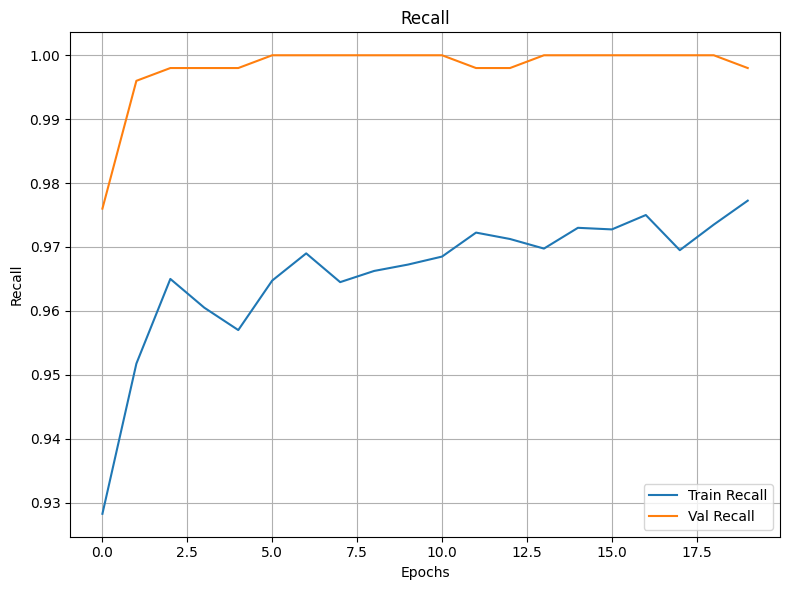

In [ ]:
plt.figure(figsize=(8,6))
plt.plot(train_recalls, label="Train Recall")
plt.plot(val_recalls, label="Val Recall")
plt.xlabel('Epochs')
plt.ylabel('Recall')
plt.title('Recall')
plt.legend()
plt.grid(True)


plt.tight_layout()
plt.show()

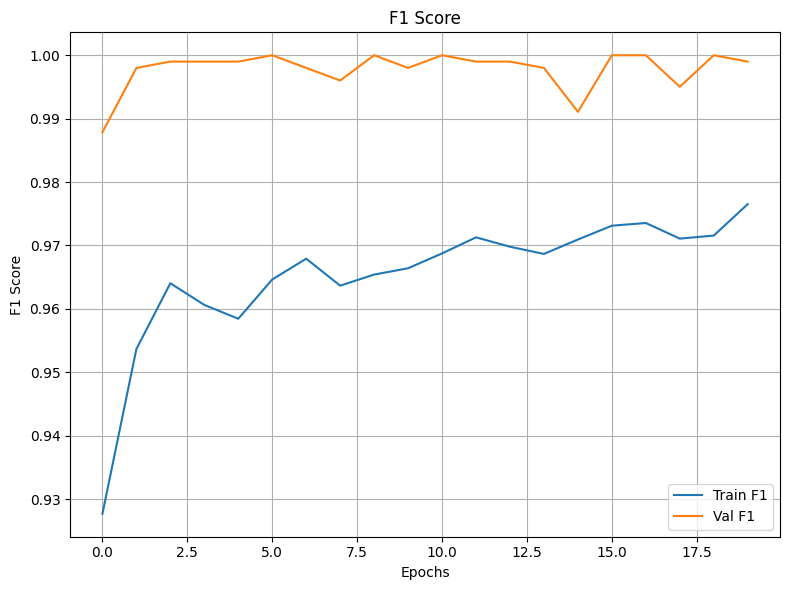

In [ ]:
plt.figure(figsize=(8,6))
plt.plot(train_f1s, label="Train F1")
plt.plot(val_f1s, label="Val F1")
plt.xlabel('Epochs')
plt.ylabel('F1 Score')
plt.title('F1 Score')
plt.legend()
plt.grid(True)


plt.tight_layout()
plt.show()

In [ ]:
# Define the paths to save the model
save_path_state_dict = "/content/drive/MyDrive/TL_ResNet-18_M1(state_dict)_colon.pth"
save_path_entire_model = "/content/drive/MyDrive/TL_ResNet-18_M1(entire_model)_colon.pth"

# 1. Save the model's state_dict (recommended way for inference and transfer learning)
torch.save(model.state_dict(), save_path_state_dict)
print(f"Model state dictionary saved to {save_path_state_dict}")

# 2. Save the entire model (includes model architecture and state_dict)
# Note: This method is less flexible for transfer learning or if the model
# definition changes, as you need the exact model class defined when loading.
torch.save(model, save_path_entire_model)
print(f"Entire model saved to {save_path_entire_model}")

Model state dictionary saved to /content/drive/MyDrive/TL_ResNet-18_M1(state_dict)_colon.pth
Entire model saved to /content/drive/MyDrive/TL_ResNet-18_M1(entire_model)_colon.pth


#Model Architecture Report: ResNet-18 (Transfer learning)


Based on the provided notebook, the methodology for training a binary classification model using transfer learning with a pre-trained ResNet-18 can be summarized as follows:

1.  **Environment Setup**:
    *   Required libraries (`torchinfo`, `torchmetrics`) were installed.
    *   Google Drive was mounted to access the dataset and save models.
    *   Necessary PyTorch, torchvision, and other libraries were imported.
    *   The computation device (GPU if available, otherwise CPU) was detected and confirmed.

2.  **Dataset Preparation**:
    *   The dataset was loaded from a specified directory structure (`/content/drive/MyDrive/colon_after_splitting`) which contains `train`, `val`, and `test` subdirectories, each with class subdirectories (`colon_aca`, `colon_n`).
    *   The number of images in each subdirectory was verified.
    *   Image transformations were defined:
        *   **Training**: Resize to 224x224, convert to Tensor, and Normalize using ImageNet mean and standard deviation.
        *   **Validation**: Resize to 224x224, convert to Tensor, and Normalize (no augmentation).
    *   `ImageFolder` was used to create datasets for training and validation, automatically inferring class labels from directory names.
    *   DataLoaders were created for training and validation sets with a specified batch size (32) and shuffling for the training set.
    *   A function `show_images_from_dataloader` was used to visualize a few images from the training DataLoader.

3.  **Model Definition (Transfer Learning)**:
    *   A pre-trained ResNet-18 model (`models.resnet18(weights=models.ResNet18_Weights.DEFAULT)`) was loaded.
    *   The weights of the feature extractor layers were frozen by setting `param.requires_grad = False` to leverage the learned features.
    *   The original fully connected (classifier) layer was replaced with a new sequential layer tailored for binary classification:
        *   `nn.Flatten()` to flatten the output of the convolutional layers.
        *   Dropout layers (`nn.Dropout(0.5)`) for regularization.
        *   Linear layers (`nn.Linear(512, 256)` and `nn.Linear(256, num_classes)` where `num_classes` is 1 for binary output).
        *   ReLU activation (`nn.ReLU()`).
    *   The model was moved to the detected device (GPU/CPU).
    *   The model summary was printed using `torchinfo.summary` to show the architecture, parameters (highlighting trainable vs. non-trainable), and estimated size.
    *   The estimated model size was also explicitly calculated and printed.

4.  **Loss Function and Optimizer**:
    *   `nn.BCEWithLogitsLoss()` was chosen as the loss function, suitable for binary classification with logits output from the model.
    *   The Adam optimizer (`optim.Adam`) was used, optimizing only the trainable parameters (the newly added fully connected layers) with a learning rate of 1e-3.

5.  **Training Process**:
    *   A training loop was implemented for a specified number of epochs (20).
    *   Inside the loop:
        *   `model.train()` was called to enable training-specific layers like Dropout and BatchNorm.
        *   The loop iterated through the training DataLoader, moving data to the specified device.
        *   A forward pass was performed, loss was calculated, gradients were zeroed, backpropagation was performed, and optimizer stepped to update parameters.
        *   Training loss and accuracy were calculated per batch and accumulated for the epoch.
        *   Predictions and true labels were collected for calculating additional metrics.
        *   After each training epoch, `model.eval()` was called to disable training-specific layers for evaluation.
        *   A validation loop was run with `torch.no_grad()` to disable gradient calculation, iterating through the validation DataLoader and calculating validation loss and accuracy.
        *   Validation predictions and true labels were also collected.
        *   Precision, Recall, and F1-score were calculated for both training and validation sets after each epoch using `sklearn.metrics`, specifically for the positive class ('colon_aca' mapped to 0).
        *   All metrics were stored in lists.
        *   Metrics were saved to a JSON file (`training_metrics_ResNet-18.json`) after each epoch.
        *   Epoch-wise training and validation loss and accuracy, precision, recall, and F1 scores were printed.
    *   The total training time was measured and printed.

6.  **Evaluation and Visualization**:
    *   Saved metrics were loaded from the JSON file.
    *   Confusion matrices for the validation set were computed and plotted using `sklearn.metrics.confusion_matrix` and `sklearn.metrics.ConfusionMatrixDisplay`.
    *   A helper function `compute_confusion_matrix` was defined to encapsulate the process of computing and plotting the confusion matrix and printing the classification report.
    *   Plots were generated to visualize the training and validation curves for:
        *   Accuracy
        *   Loss
        *   Precision
        *   Recall
        *   F1 Score

7.  **Model Saving**:
    *   The trained model's state dictionary was saved to a `.pth` file (`/content/drive/MyDrive/models/TL/mobilenetv2_colon_state_dict_M4.pth`).
    *   The entire model (architecture and state dictionary) was also saved to a separate `.pth` file (`/content/drive/MyDrive/models/TL/mobilenetv2_colon_entire_model_M4.pth`).

8.  **Verification**:
    *   A check was performed using `glob` to confirm that there was no overlap between the training and validation file paths, ensuring data split integrity.

in the augmentaion it must follow the sequence :
- *Resize → Augmentations → ToTensor → Normalize*

`ToTensor()` must come **AFTER** `Normlize()`

- *Direct resize to 224 → if the images are squere \
Resize(256) + Crop(224) → images are not squeere*